In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#passing the file to pandas to read it and display it
data = pd.read_csv("/content/African_crises_dataset.csv")
data

,country_number,country_code,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,70,ZWE,Zimbabwe,2009,1,354.800000,1,1,0.0,-7.670000,1,1,0,crisis
1055,70,ZWE,Zimbabwe,2010,0,378.200000,1,1,0.0,3.217000,1,0,0,no_crisis
1056,70,ZWE,Zimbabwe,2011,0,361.900000,1,1,0.0,4.920000,1,0,0,no_crisis
1057,70,ZWE,Zimbabwe,2012,0,361.900000,1,1,0.0,3.720000,1,0,0,no_crisis


In [ ]:
#general information about the dataset e.g rows and columns and their data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_number                   1059 non-null   int64  
 1   country_code                     1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

In [ ]:
#checking the statistics of all  data
data.describe()

,country_number,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000,1059.000000,1059.000000
mean,35.613787,1967.767705,0.077432,43.140831,0.039660,0.152975,0.006402,2.084889e+04,0.776204,0.132200,0.129367
std,23.692402,33.530632,0.267401,111.475380,0.195251,0.360133,0.043572,6.757274e+05,0.416984,0.349847,0.335765
min,1.000000,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.850214e+01,0.000000,0.000000,0.000000
25%,15.000000,1951.000000,0.000000,0.195350,0.000000,0.000000,0.000000,2.086162e+00,1.000000,0.000000,0.000000
50%,38.000000,1973.000000,0.000000,0.868400,0.000000,0.000000,0.000000,5.762330e+00,1.000000,0.000000,0.000000
75%,56.000000,1994.000000,0.000000,8.462750,0.000000,0.000000,0.000000,1.164405e+01,1.000000,0.000000,0.000000
max,70.000000,2014.000000,1.000000,744.306139,1.000000,1.000000,0.400000,2.198970e+07,1.000000,2.000000,1.000000


In [ ]:
#checking for missing values
data.isnull().sum()

,0
country_number,0
country_code,0
country,0
year,0
systemic_crisis,0
exch_usd,0
domestic_debt_in_default,0
sovereign_external_debt_default,0
gdp_weighted_default,0
inflation_annual_cpi,0


In [ ]:
#checking for duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
#checking some rows for each feature
for columns in data:
  print(data[columns].sort_values().head(10))

0     1
1     1
2     1
19    1
36    1
37    1
38    1
39    1
40    1
41    1
Name: country_number, dtype: int64
98     AGO
116    AGO
117    AGO
118    AGO
119    AGO
120    AGO
121    AGO
122    AGO
123    AGO
124    AGO
Name: country_code, dtype: object
0     Algeria
62    Algeria
60    Algeria
59    Algeria
58    Algeria
57    Algeria
56    Algeria
55    Algeria
54    Algeria
53    Algeria
Name: country, dtype: object
283    1860
284    1861
285    1862
286    1863
287    1864
288    1865
289    1866
290    1867
291    1868
292    1869
Name: year, dtype: int64
694    0
708    0
701    0
700    0
699    0
698    0
697    0
696    0
695    0
709    0
Name: systemic_crisis, dtype: int64
652    0.0
653    0.0
654    0.0
655    0.0
656    0.0
659    0.0
657    0.0
658    0.0
651    0.0
649    0.0
Name: exch_usd, dtype: float64
690    0
698    0
697    0
696    0
695    0
694    0
693    0
692    0
691    0
699    0
Name: domestic_debt_in_default, dtype: int64
1043    0
18      0
17   

In [ ]:
#dropping some features that don't relate to my target valuable
data = data.drop(columns = ["country_number","country_code","country","year","currency_crises","inflation_crises","banking_crisis"])
data
#decided to drop the country features and the year because the goal with this prediction model is to predict and i need to make sure it's accurate predicting the crisis with no bias
#i dropped currency , inflation and banking crisis because the goal of the model is to predict when a systemic crisis occurs.
#if i left the other crisies my model won't be efficient because the others are determined by systemic error and would onlyy look at three columns and may lead to overfitting(data leakage)

,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence
0,1,0.052264,0,0,0.0,3.441456,0
1,0,0.052798,0,0,0.0,14.149140,0
2,0,0.052274,0,0,0.0,-3.718593,0
3,0,0.051680,0,0,0.0,11.203897,0
4,0,0.051308,0,0,0.0,-3.848561,0
...,...,...,...,...,...,...,...
1054,1,354.800000,1,1,0.0,-7.670000,1
1055,0,378.200000,1,1,0.0,3.217000,1
1056,0,361.900000,1,1,0.0,4.920000,1
1057,0,361.900000,1,1,0.0,3.720000,1


In [ ]:
# i didn't encode any features as they are all numerical

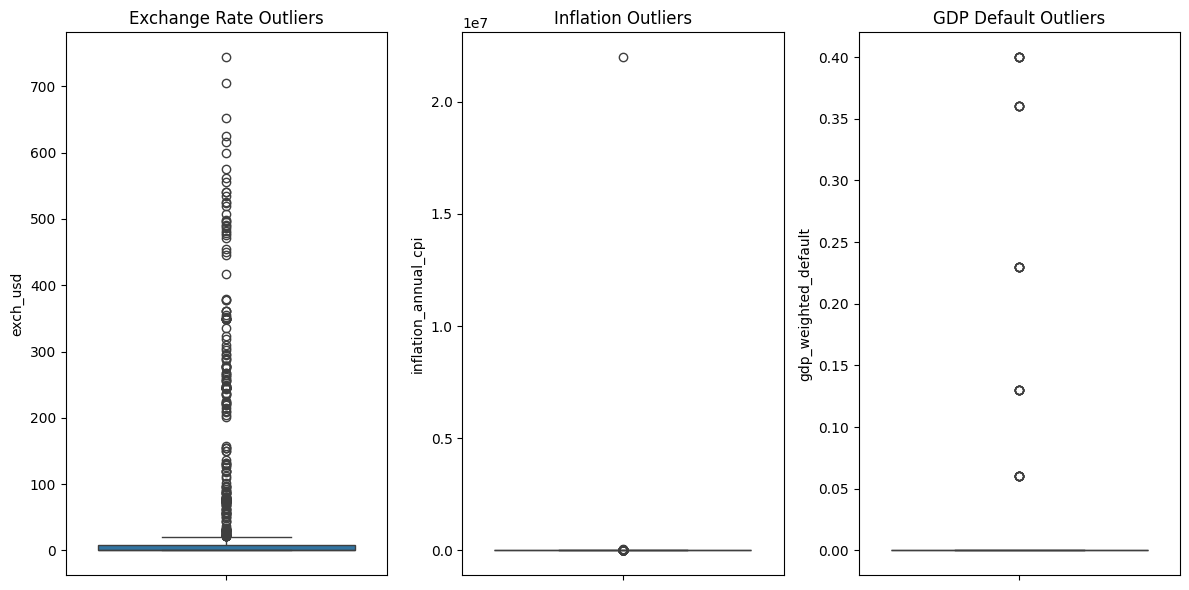

In [ ]:
#checking anomalies for numerical values left
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=data['exch_usd'])
plt.title('Exchange Rate Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=data['inflation_annual_cpi'])
plt.title('Inflation Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=data['gdp_weighted_default'])
plt.title('GDP Default Outliers')

plt.tight_layout()
plt.show()

In [ ]:
#since these outliers are very crucial to determine a financial crisis i am going to use the robust scaler technique to handle extreme outliers
scale = RobustScaler()
columns_to_scale = ["exch_usd","inflation_annual_cpi","gdp_weighted_default"]
data[columns_to_scale] = scale.fit_transform(data[columns_to_scale])

In [ ]:
#final display
data

,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence
0,1,-0.098717,0,0,0.0,-0.242823,0
1,0,-0.098653,0,0,0.0,0.877475,0
2,0,-0.098716,0,0,0.0,-0.991948,0
3,0,-0.098788,0,0,0.0,0.569327,0
4,0,-0.098833,0,0,0.0,-1.005546,0
...,...,...,...,...,...,...,...
1054,1,42.810509,1,1,0.0,-1.405366,1
1055,0,45.640903,1,1,0.0,-0.266307,1
1056,0,43.669304,1,1,0.0,-0.088129,1
1057,0,43.669304,1,1,0.0,-0.213680,1


In [ ]:
columns_heatmap = ["exch_usd","domestic_debt_in_default","sovereign_external_debt_default","gdp_weighted_default","inflation_annual_cpi","independence","systemic_crisis"]
correlation_matrix = data[columns_heatmap].corr()
fig = px.imshow(correlation_matrix, text_auto=True, title="Correlation Heatmap of Financial Indicators")
fig.show()

In [ ]:
#setting target and feature variables
x = data[["exch_usd","domestic_debt_in_default","sovereign_external_debt_default","gdp_weighted_default","inflation_annual_cpi","independence"]]
y = data["systemic_crisis"]

In [ ]:
#splitting test and train
x_train , x_test , y_train , y_test = train_test_split(x,y,train_size=0.3, random_state=42)

In [ ]:
#prediction using random forest
rfc = RandomForestClassifier(n_estimators=100)
rfc .fit(x_train , y_train)
y_pred = rfc.predict(x_test)
print(f"predicted systemic crisis {y_pred}")



predicted systemic crisis [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
#checking accuracy
print(("accuracy = {:.2f}").format(rfc.score(x_test,y_test)))

accuracy = 0.93


<Axes: xlabel='Predicted', ylabel='Actual'>

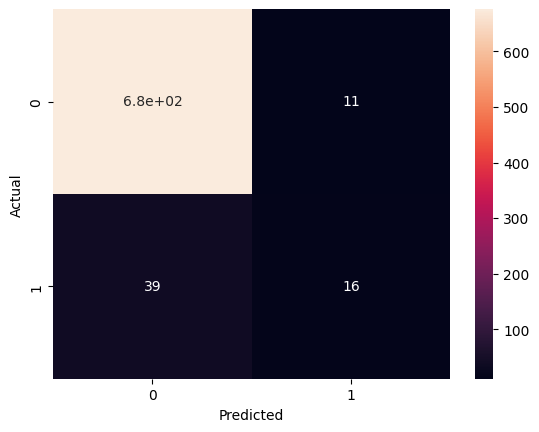

In [ ]:
#confusion matrix
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(confusion_matrix,annot=True)

In [ ]:
#my model displayed an accuracy of 0.92 which is moderateley well but the whole point of this model is to catch a systemic error before it happens and if you look at the false negative the number is biased because there is alot of zeros than ones in this data set